Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device (forced CPU per Stage 2A spec): cpu
✅ GGNN loaded | input_dim=101 hidden=256 steps=5
✅ YOLOv5n loaded
Upload a photo from your phone


Saving Image1.png to Image1 (1).png


Saving Image2.jpg to Image2 (1).jpg

--- Testing: Image1 (1).png ---

Task 1: step on something
  Image loaded: 640x640
[Stage 1] YOLOv5n detection...
  Found 19 objects: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase', 'cup', 'wine glass', 'bottle', 'scissors', 'dining table', 'potted plant', 'spoon', 'knife', 'scissors']
[Stage 2] Building 101-dim node features...
  Graph: 19 nodes x 101 features
[Stage 3] GGNN task ranking...

RESULT for 'step on something':
  Best object : CHAIR
  YOLOv5n conf: 0.716
  GGNN score  : 4.0333


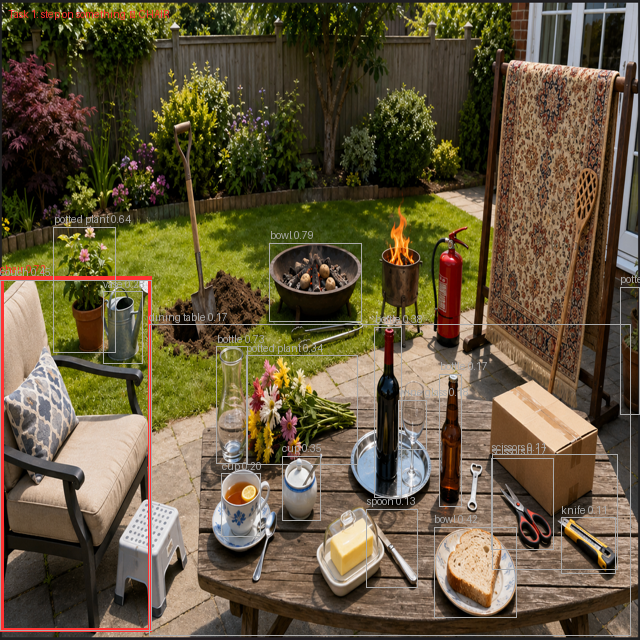



Task 2: sit comfortably
  Image loaded: 640x640
[Stage 1] YOLOv5n detection...
  Found 19 objects: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase', 'cup', 'wine glass', 'bottle', 'scissors', 'dining table', 'potted plant', 'spoon', 'knife', 'scissors']
[Stage 2] Building 101-dim node features...
  Graph: 19 nodes x 101 features
[Stage 3] GGNN task ranking...

RESULT for 'sit comfortably':
  Best object : COUCH
  YOLOv5n conf: 0.447
  GGNN score  : 3.9651


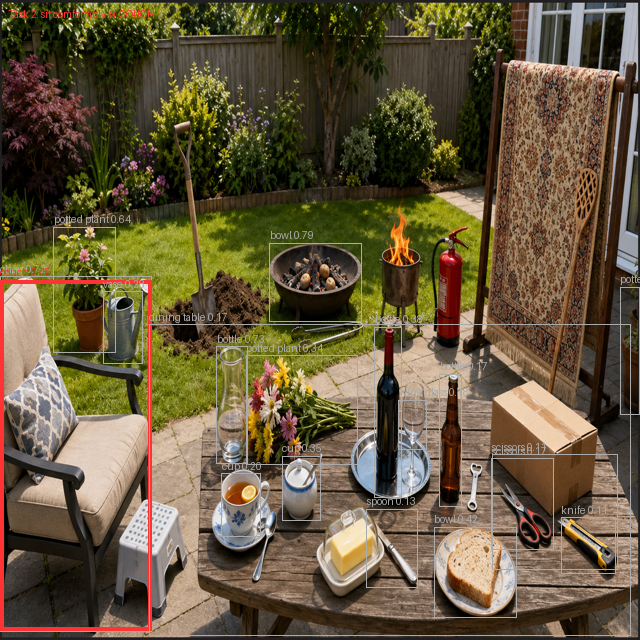



Task 3: place flowers in
  Image loaded: 640x640
[Stage 1] YOLOv5n detection...
  Found 19 objects: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase', 'cup', 'wine glass', 'bottle', 'scissors', 'dining table', 'potted plant', 'spoon', 'knife', 'scissors']
[Stage 2] Building 101-dim node features...
  Graph: 19 nodes x 101 features
[Stage 3] GGNN task ranking...

RESULT for 'place flowers in':
  Best object : BOTTLE
  YOLOv5n conf: 0.725
  GGNN score  : 0.0831


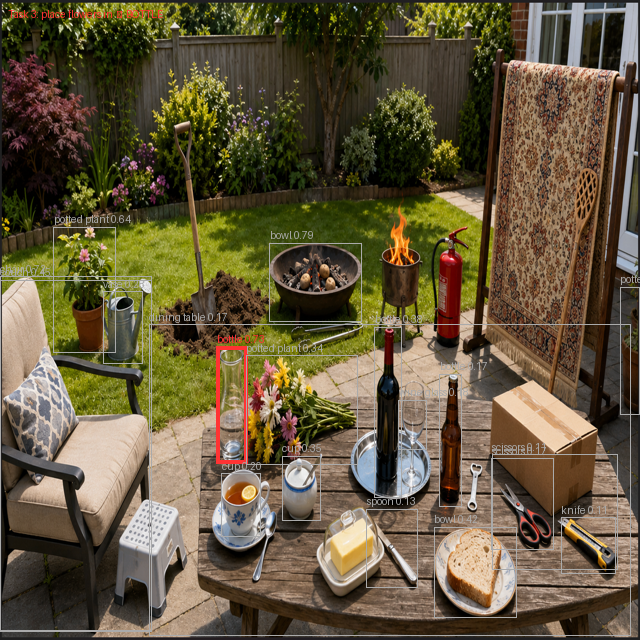



Task 4: get potatoes out of fire
  Image loaded: 640x640
[Stage 1] YOLOv5n detection...
  Found 19 objects: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase', 'cup', 'wine glass', 'bottle', 'scissors', 'dining table', 'potted plant', 'spoon', 'knife', 'scissors']
[Stage 2] Building 101-dim node features...
  Graph: 19 nodes x 101 features
[Stage 3] GGNN task ranking...

RESULT for 'get potatoes out of fire':
  Best object : KNIFE
  YOLOv5n conf: 0.112
  GGNN score  : 0.9408


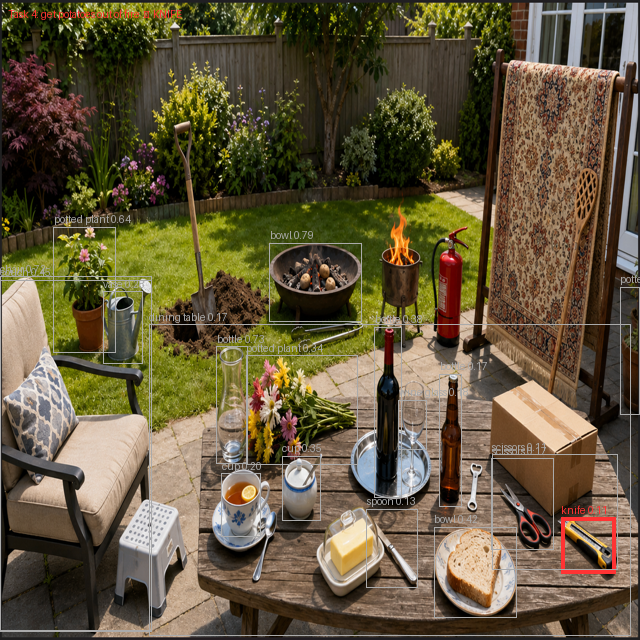



Task 12: smear butter
  Image loaded: 640x640
[Stage 1] YOLOv5n detection...
  Found 19 objects: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase', 'cup', 'wine glass', 'bottle', 'scissors', 'dining table', 'potted plant', 'spoon', 'knife', 'scissors']
[Stage 2] Building 101-dim node features...
  Graph: 19 nodes x 101 features
[Stage 3] GGNN task ranking...

RESULT for 'smear butter':
  Best object : SPOON
  YOLOv5n conf: 0.134
  GGNN score  : 4.3943


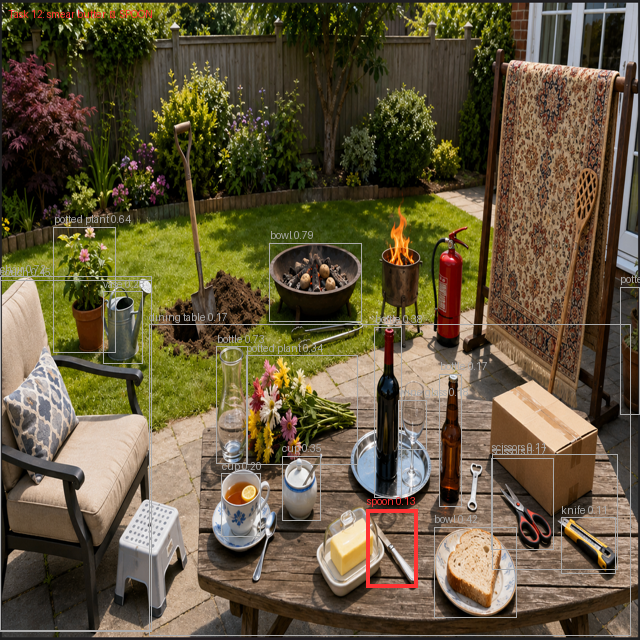


Image: Image1 (1).png
Detected: ['bowl', 'bottle', 'chair', 'potted plant', 'couch', 'bowl', 'bottle', 'cup', 'potted plant', 'vase']

Task | Task Name                      | Best Object          | Score
---------------------------------------------------------------------------
   1 | step on something              | chair                | 3.2556
   2 | sit comfortably                | couch                | 3.3831
   3 | place flowers in               | bottle               | -0.0543
   4 | get potatoes out of fire       | bowl                 | 0.8075
   5 | water a plant                  | bowl                 | 1.0914
   6 | get lemon out of tea           | bottle               | 0.2266
   7 | dig a hole                     | bowl                 | 0.7193
   8 | open a bottle of beer          | chair                | 2.9273
   9 | open a parcel                  | bottle               | -5.3599
  10 | serve wine                     | cup                  | 0.0834
  11 | pour sugar

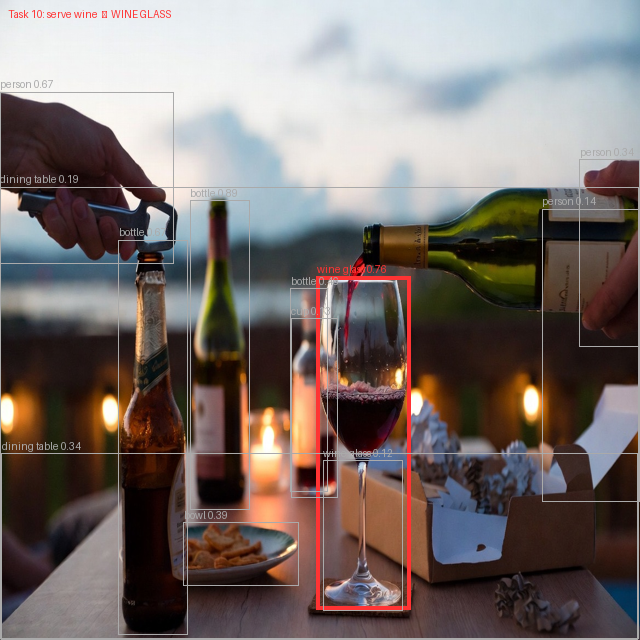


Image: Image2 (1).jpg
Detected: ['bottle', 'wine glass', 'bottle', 'person', 'bottle', 'bowl', 'person', 'dining table']

Task | Task Name                      | Best Object          | Score
---------------------------------------------------------------------------
   1 | step on something              | dining table         | -1.4920
   2 | sit comfortably                | dining table         | -1.8313
   3 | place flowers in               | bottle               | 2.5771
   4 | get potatoes out of fire       | bottle               | 3.0437
   5 | water a plant                  | bottle               | 2.0180
   6 | get lemon out of tea           | bottle               | 1.3665
   7 | dig a hole                     | bottle               | 1.8933
   8 | open a bottle of beer          | dining table         | 2.9916
   9 | open a parcel                  | bottle               | -1.1735
  10 | serve wine                     | wine glass           | 3.4208
  11 | pour sugar            

In [36]:
# ================================================================
# TAOD-Lite: Full Software Pipeline Simulation
# Paste this entire script into ONE Google Colab cell and run it.
# ================================================================

# ---- CELL 1: Install ----
import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"])

import os, json, torch, torch.nn as nn
import numpy as np
from PIL import Image, ImageDraw
import requests
from io import BytesIO
from collections import defaultdict
from google.colab import drive

# Mount Drive (your checkpoint is here)
drive.mount('/content/drive')

CHECKPOINT_PATH = "/content/drive/MyDrive/TAOD_GGNN/checkpoints/best_ggnn_ranker_v2.pt"
'''DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")'''
# Stage 2A requirement: CPU-only inference
DEVICE = "cpu"
torch.set_num_threads(4)
print(f"Device (forced CPU per Stage 2A spec): {DEVICE}")

# ================================================================
# TASK NAMES
# ================================================================
TASK_NAMES = {
    1:"step on something", 2:"sit comfortably", 3:"place flowers in",
    4:"get potatoes out of fire", 5:"water a plant", 6:"get lemon out of tea",
    7:"dig a hole", 8:"open a bottle of beer", 9:"open a parcel",
    10:"serve wine", 11:"pour sugar", 12:"smear butter",
    13:"extinguish fire", 14:"pound a carpet"
}

COCO_CLASSES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck',
    'boat','traffic light','fire hydrant','stop sign','parking meter','bench',
    'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra',
    'giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee',
    'skis','snowboard','sports ball','kite','baseball bat','baseball glove',
    'skateboard','surfboard','tennis racket','bottle','wine glass','cup',
    'fork','knife','spoon','bowl','banana','apple','sandwich','orange',
    'broccoli','carrot','hot dog','pizza','donut','cake','chair','couch',
    'potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear',
    'hair drier','toothbrush'
]

# ================================================================
# GGNN MODEL — matches your trained checkpoint exactly
# ================================================================
class GGNNRanker(nn.Module):
    def __init__(self, input_dim=101, hidden_dim=256, num_steps=5, dropout=0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_steps  = num_steps

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU()
        )
        self.message_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim, bias=False), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim, bias=False)
        )
        self.gru      = nn.GRUCell(hidden_dim, hidden_dim)
        self.out_norm = nn.LayerNorm(hidden_dim)
        self.score_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, adj, mask):
        B, N, _ = x.shape
        h = self.input_proj(x)
        for _ in range(self.num_steps):
            messages   = self.message_layer(h)
            aggregated = torch.bmm(adj, messages)
            h_new = self.gru(
                aggregated.reshape(B*N, self.hidden_dim),
                h.reshape(B*N, self.hidden_dim)
            ).reshape(B, N, self.hidden_dim)
            h = self.out_norm(h + h_new)
            h = torch.where(mask.unsqueeze(-1), h, torch.zeros_like(h))
        scores = self.score_head(h).squeeze(-1)
        scores = scores.masked_fill(~mask, float('-inf'))
        return scores

# ================================================================
# LOAD GGNN CHECKPOINT
# ================================================================
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
ggnn = GGNNRanker(
    input_dim  = ckpt["input_dim"],
    hidden_dim = ckpt["hidden_dim"],
    num_steps  = ckpt["num_steps"],
    dropout    = 0.0
).to(DEVICE)
ggnn.load_state_dict(ckpt["model_state_dict"])
ggnn.eval()
print(f"✅ GGNN loaded | input_dim={ckpt['input_dim']} "
      f"hidden={ckpt['hidden_dim']} steps={ckpt['num_steps']}")

# ================================================================
# LOAD YOLOv5n
# ================================================================
from ultralytics import YOLO
yolo = YOLO('yolov5n.pt')
print("✅ YOLOv5n loaded")

# ================================================================
# FEATURE BUILDER — matches your notebook exactly
# ================================================================
NUM_COCO  = 80
NUM_TASKS = 14

def build_features(detections, task_id, img_w=640, img_h=640, max_nodes=60):
    feats = []
    for d in detections[:max_nodes]:
        x1,y1,x2,y2 = d['xmin'], d['ymin'], d['xmax'], d['ymax']
        # Normalise
        nx1,ny1 = x1/img_w, y1/img_h
        nx2,ny2 = x2/img_w, y2/img_h
        nx1,ny1,nx2,ny2 = [np.clip(v,0,1) for v in [nx1,ny1,nx2,ny2]]
        w  = max(nx2-nx1, 1e-6)
        h  = max(ny2-ny1, 1e-6)
        cx, cy = nx1+w/2, ny1+h/2
        area   = w*h
        log_ar = float(np.clip(np.log(w/h+1e-6)/3.0, -1, 1))
        conf   = float(d['conf'])

        cls_oh  = np.zeros(NUM_COCO,  dtype=np.float32)
        task_oh = np.zeros(NUM_TASKS, dtype=np.float32)
        cid = int(d['class_id'])
        if 0 <= cid < NUM_COCO: cls_oh[cid] = 1.0
        tid = int(task_id) - 1
        if 0 <= tid < NUM_TASKS: task_oh[tid] = 1.0

        feats.append(np.concatenate(
            [[cx,cy,w,h,area,log_ar,conf], cls_oh, task_oh]
        ))  # 6+1+80+14 = 101

    if not feats:
        return None, 0
    F = np.stack(feats).astype(np.float32)   # (N, 101)
    return F, len(feats)

def build_adj(N):
    """Fully-connected row-normalised adjacency matrix."""
    adj = np.ones((N, N), dtype=np.float32)
    np.fill_diagonal(adj, 0)
    row_sum = adj.sum(axis=1, keepdims=True).clip(min=1)
    return adj / row_sum

# ================================================================
# FULL PIPELINE
# ================================================================
def run_pipeline(image_input, task_id, save_path='taod_result.jpg'):
    print(f"\n{'='*55}")
    print(f"Task {task_id}: {TASK_NAMES[task_id]}")
    print('='*55)

    # Load image — with proper headers
    if isinstance(image_input, str) and image_input.startswith('http'):
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(image_input, timeout=15, headers=headers)
        img = Image.open(BytesIO(r.content)).convert('RGB')
    else:
        img = Image.open(image_input).convert('RGB')
    img = img.resize((640, 640))
    W, H = img.size
    print(f"  Image loaded: {W}x{H}")

    # Stage 1
    print("[Stage 1] YOLOv5n detection...")
    results = yolo.predict(img, conf=0.10, iou=0.45, verbose=False)
    dets = []
    for r in results:
        for box in r.boxes:
            xy  = box.xyxy[0].cpu().numpy()
            cid = int(box.cls[0].cpu())
            dets.append({
                'xmin':float(xy[0]), 'ymin':float(xy[1]),
                'xmax':float(xy[2]), 'ymax':float(xy[3]),
                'conf':float(box.conf[0].cpu()),
                'class_id':cid,
                'class_name': COCO_CLASSES[cid] if cid < 80 else 'unknown'
            })
    print(f"  Found {len(dets)} objects: {[d['class_name'] for d in dets]}")
    if not dets:
        print("  No objects detected. Try a different image.")
        return None

    # Stage 2
    print("[Stage 2] Building 101-dim node features...")
    feats, N = build_features(dets, task_id, W, H)
    print(f"  Graph: {N} nodes x 101 features")

    # Stage 3
    print("[Stage 3] GGNN task ranking...")
    feat_t = torch.from_numpy(feats).unsqueeze(0).to(DEVICE)
    adj_t  = torch.from_numpy(build_adj(N)).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, N, dtype=torch.bool).to(DEVICE)
    with torch.no_grad():
        scores = ggnn(feat_t, adj_t, mask_t)
    scores_np = scores[0].cpu().numpy()
    best_idx  = int(np.argmax(scores_np))
    winner    = dets[best_idx]

    print(f"\n{'='*55}")
    print(f"RESULT for '{TASK_NAMES[task_id]}':")
    print(f"  Best object : {winner['class_name'].upper()}")
    print(f"  YOLOv5n conf: {winner['conf']:.3f}")
    print(f"  GGNN score  : {scores_np[best_idx]:.4f}")
    print(f"{'='*55}")

    # Visualise
    draw = ImageDraw.Draw(img)
    for i, d in enumerate(dets):
        color = '#FF3333' if i == best_idx else '#AAAAAA'
        width = 4 if i == best_idx else 1
        draw.rectangle([d['xmin'],d['ymin'],d['xmax'],d['ymax']],
                       outline=color, width=width)
        draw.text((d['xmin'], max(0, d['ymin']-14)),
                  f"{d['class_name']} {d['conf']:.2f}", fill=color)
    draw.text((8, 8),
              f"Task {task_id}: {TASK_NAMES[task_id]}  →  {winner['class_name'].upper()}",
              fill='#FF3333')
    img.save(save_path)
    return img

# ================================================================
# RUN DEMO — change image URL and task_id here
# ================================================================
'''from IPython.display import display

# Good test images (living room / kitchen / garden):
IMAGE_URL = "https://images.unsplash.com/photo-1555041469-a586c61ea9bc?w=640"

# Try task 2 first (sit comfortably) — easy to validate visually
result = run_pipeline(IMAGE_URL, task_id=2, save_path='/content/result_task2.jpg')
if result:
    display(result)'''

from google.colab import files
from IPython.display import display

print("Upload a photo from your phone")
uploaded1 = files.upload()
uploaded2 = files.upload()
'''uploaded3 = files.upload()
uploaded4 = files.upload()
uploaded5 = files.upload()'''

for fname in uploaded1.keys():
    print(f"\n--- Testing: {fname} ---")
    # Try multiple tasks on each photo
    for task_id in [1, 2, 3, 4, 12]:
        result = run_pipeline(fname, task_id=task_id,
                             save_path=f'/content/result_{fname}_task{task_id}.jpg')
        if result:
            display(result)
            print()

# Use the last uploaded photo (uploaded5)
last_fname = list(uploaded1.keys())[0] if uploaded1 else list(uploaded1.keys())[0]
img_raw = Image.open(last_fname).convert('RGB').resize((640, 640))

res = yolo.predict(img_raw, conf=0.25, iou=0.45, verbose=False)
dets_all = []
for r in res:
    for box in r.boxes:
        xy  = box.xyxy[0].cpu().numpy()
        cid = int(box.cls[0].cpu())
        dets_all.append({
            'xmin':float(xy[0]),'ymin':float(xy[1]),
            'xmax':float(xy[2]),'ymax':float(xy[3]),
            'conf':float(box.conf[0].cpu()),
            'class_id':cid,
            'class_name': COCO_CLASSES[cid] if cid < 80 else 'unknown'
        })

print(f"Image: {last_fname}")
print(f"Detected: {[d['class_name'] for d in dets_all]}\n")
print(f"{'Task':>4} | {'Task Name':<30} | {'Best Object':<20} | Score")
print("-" * 75)

for tid in range(1, 15):
    if not dets_all:
        print(f"{tid:>4} | {TASK_NAMES[tid]:<30} | {'no detection':<20} | -")
        continue
    feats, N = build_features(dets_all, tid)
    feat_t = torch.from_numpy(feats).unsqueeze(0).to(DEVICE)
    adj_t  = torch.from_numpy(build_adj(N)).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, N, dtype=torch.bool).to(DEVICE)
    with torch.no_grad():
        sc = ggnn(feat_t, adj_t, mask_t)[0].cpu().numpy()
    bi = int(np.argmax(sc))
    print(f"{tid:>4} | {TASK_NAMES[tid]:<30} | {dets_all[bi]['class_name']:<20} | {sc[bi]:.4f}")

print("-" * 75)

for fname in uploaded2.keys():
    print(f"\n--- Testing: {fname} ---")
    # Try multiple tasks on each photo
    for task_id in [10]:
        result = run_pipeline(fname, task_id=task_id,
                             save_path=f'/content/result_{fname}_task{task_id}.jpg')
        if result:
            display(result)
            print()

# Use the last uploaded photo (uploaded5)
last_fname = list(uploaded2.keys())[0] if uploaded2 else list(uploaded2.keys())[0]
img_raw = Image.open(last_fname).convert('RGB').resize((640, 640))

res = yolo.predict(img_raw, conf=0.25, iou=0.45, verbose=False)
dets_all = []
for r in res:
    for box in r.boxes:
        xy  = box.xyxy[0].cpu().numpy()
        cid = int(box.cls[0].cpu())
        dets_all.append({
            'xmin':float(xy[0]),'ymin':float(xy[1]),
            'xmax':float(xy[2]),'ymax':float(xy[3]),
            'conf':float(box.conf[0].cpu()),
            'class_id':cid,
            'class_name': COCO_CLASSES[cid] if cid < 80 else 'unknown'
        })

print(f"Image: {last_fname}")
print(f"Detected: {[d['class_name'] for d in dets_all]}\n")
print(f"{'Task':>4} | {'Task Name':<30} | {'Best Object':<20} | Score")
print("-" * 75)

for tid in range(1, 15):
    if not dets_all:
        print(f"{tid:>4} | {TASK_NAMES[tid]:<30} | {'no detection':<20} | -")
        continue
    feats, N = build_features(dets_all, tid)
    feat_t = torch.from_numpy(feats).unsqueeze(0).to(DEVICE)
    adj_t  = torch.from_numpy(build_adj(N)).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, N, dtype=torch.bool).to(DEVICE)
    with torch.no_grad():
        sc = ggnn(feat_t, adj_t, mask_t)[0].cpu().numpy()
    bi = int(np.argmax(sc))
    print(f"{tid:>4} | {TASK_NAMES[tid]:<30} | {dets_all[bi]['class_name']:<20} | {sc[bi]:.4f}")

print("-" * 75)
